In [1]:
import sys
!{sys.executable} -m pip install --no-cache-dir --no-deps -q \
    transformers==4.44.2 datasets==2.21.0 accelerate==0.34.2 evaluate==0.4.2 \
    tokenizers==0.19.1 huggingface_hub==0.24.6

In [2]:
import transformers, datasets, accelerate, evaluate
print(transformers.__version__, datasets.__version__, accelerate.__version__, evaluate.__version__)

4.44.2 2.21.0 0.34.2 0.4.2


In [3]:
import sys
!{sys.executable} -m pip uninstall -y -q peft

In [4]:
import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback,
)
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Using device: cuda
GPU: Tesla T4


In [5]:
# Adjust the path based on how it appears after adding the Kaggle dataset
DATA_PATH = "/kaggle/input/datasets/organizations/databricks/databricks-dolly-15k/databricks-dolly-15k.jsonl"

records = []
with open(DATA_PATH, "r") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
print(df.shape)
print(df.columns.tolist())
df.head()

(15015, 4)
['instruction', 'context', 'response', 'category']


,instruction,context,response,category
0,When did Virgin Australia start operating?,"Virgin Australia, the trading name of Virgin A...",Virgin Australia commenced services on 31 Augu...,closed_qa
1,Which is a species of fish? Tope or Rope,,Tope,classification
2,Why can camels survive for long without water?,,Camels use the fat in their humps to keep them...,open_qa
3,"Alice's parents have three daughters: Amy, Jes...",,The name of the third daughter is Alice,open_qa
4,When was Tomoaki Komorida born?,Komorida was born in Kumamoto Prefecture on Ju...,"Tomoaki Komorida was born on July 10,1981.",closed_qa


In [ ]:
df.shape

In [6]:
def format_example(row):
    instruction = row["instruction"]
    context = row.get("context", "")
    response = row["response"]

    if context and str(context).strip():
        prompt = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Context:\n{context}\n\n"
            f"### Response:\n{response}"
        )
    else:
        prompt = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Response:\n{response}"
        )
    return prompt

df["text"] = df.apply(format_example, axis=1)
print(df["text"].iloc[0])

### Instruction:
When did Virgin Australia start operating?

### Context:
Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.[3] It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.[4]

### Response:
Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.


In [7]:
df = df.sample(n=12000, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

train_texts = train_df["text"].tolist()
val_texts = val_df["text"].tolist()
test_texts = test_df["text"].tolist()

Train: 9600, Val: 1200, Test: 1200


In [8]:
model_name = "facebook/opt-125m"

tokenizer = AutoTokenizer.from_pretrained(model_name)

# OPT tokenizer has no pad token by default
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

MAX_LENGTH = 256

def tokenize_function(texts):
    return tokenizer(
        texts,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        return_tensors=None
    )

train_encodings = tokenize_function(train_texts)
val_encodings = tokenize_function(val_texts)
test_encodings = tokenize_function(test_texts)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [9]:
class DollyDataset(Dataset):
    def __init__(self, encodings):
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[idx], dtype=torch.long),
        }

train_dataset = DollyDataset(train_encodings)
val_dataset = DollyDataset(val_encodings)
test_dataset = DollyDataset(test_encodings)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 9600
Val dataset size: 1200
Test dataset size: 1200


In [10]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # causal LM, not masked LM
)

In [11]:
model = AutoModelForCausalLM.from_pretrained(model_name)
model.resize_token_embeddings(len(tokenizer))
model.to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model: {model_name}")
print(f"Total parameters: {num_params:,}")

Model: facebook/opt-125m
Total parameters: 125,233,920


In [12]:
%load_ext tensorboard

LOG_DIR = "/kaggle/working/logs"
os.makedirs(LOG_DIR, exist_ok=True)

%tensorboard --logdir {LOG_DIR}

<IPython.core.display.Javascript object>

In [13]:
OUTPUT_DIR = "/kaggle/working/opt125m-dolly-finetuned"
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_steps=100,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to=["tensorboard"],
    logging_dir=LOG_DIR,
    seed=42,
    dataloader_num_workers=2,
)

In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [15]:
train_result = trainer.train()

print("Training complete.")
print(train_result.metrics)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,2.633100,2.548277
2,2.449100,2.520377
3,2.296600,2.516848


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Training complete.
{'train_runtime': 1414.4199, 'train_samples_per_second': 20.362, 'train_steps_per_second': 0.636, 'total_flos': 3762605260800000.0, 'train_loss': 2.4874101214938693, 'epoch': 3.0}


Validation loss per epoch:
Epoch 1.0: val_loss = 2.5483
Epoch 2.0: val_loss = 2.5204
Epoch 3.0: val_loss = 2.5168


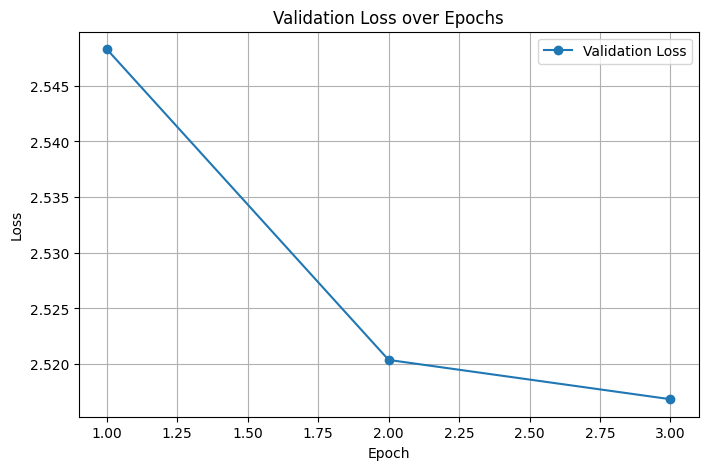

In [16]:
log_history = trainer.state.log_history

train_losses = [(entry["epoch"], entry["loss"]) for entry in log_history if "loss" in entry]
val_losses = [(entry["epoch"], entry["eval_loss"]) for entry in log_history if "eval_loss" in entry]

print("Validation loss per epoch:")
for epoch, loss in val_losses:
    print(f"Epoch {epoch:.1f}: val_loss = {loss:.4f}")

import matplotlib.pyplot as plt

val_epochs = [e for e, _ in val_losses]
val_vals = [l for _, l in val_losses]

plt.figure(figsize=(8, 5))
plt.plot(val_epochs, val_vals, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss over Epochs")
plt.legend()
plt.grid(True)
plt.savefig("/kaggle/working/val_loss_curve.png")
plt.show()

In [17]:
test_metrics = trainer.evaluate(eval_dataset=test_dataset)
print("Test set metrics:", test_metrics)

import math
test_perplexity = math.exp(test_metrics["eval_loss"])
print(f"Test Perplexity: {test_perplexity:.2f}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Test set metrics: {'eval_loss': 2.4922728538513184, 'eval_runtime': 25.8107, 'eval_samples_per_second': 46.492, 'eval_steps_per_second': 2.906, 'epoch': 3.0}
Test Perplexity: 12.09


In [18]:
FINAL_MODEL_DIR = "/kaggle/working/opt125m-dolly-final"

trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print(f"Model and tokenizer saved to {FINAL_MODEL_DIR}")
print(os.listdir(FINAL_MODEL_DIR))

Model and tokenizer saved to /kaggle/working/opt125m-dolly-final
['tokenizer.json', 'config.json', 'merges.txt', 'training_args.bin', 'vocab.json', 'model.safetensors', 'generation_config.json', 'tokenizer_config.json', 'special_tokens_map.json']


In [22]:
from transformers import AutoModelForCausalLM, AutoTokenizer

reloaded_tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_DIR)
reloaded_model = AutoModelForCausalLM.from_pretrained(FINAL_MODEL_DIR)
reloaded_model.to(device)
reloaded_model.eval()

test_prompt = (
    "### Instruction:\n"
    "Explain what machine learning is in simple terms.\n\n"
    "### Response:\n"
)

inputs = reloaded_tokenizer(test_prompt, return_tensors="pt").to(device)

with torch.no_grad():
    output_ids = reloaded_model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        top_p=0.9,
        temperature=0.7,
        repetition_penalty=1.3,
        no_repeat_ngram_size=3,
        pad_token_id=reloaded_tokenizer.pad_token_id
    )

generated_text = reloaded_tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("=== Inference Output ===")
print(generated_text)

=== Inference Output ===
### Instruction:
Explain what machine learning is in simple terms.

### Response:
Machine Learning (ML) or ML is a computer model that can be trained using the inputs of natural language processing methods such as neural networks and deep learning systems. It has been described by various authors, including Cramer et al., and it is based on the assumption that human knowledge is infinite.[1] In general, ML uses two-dimensional models to analyze data from many sources and produce output which are more than 100% accurate at predicting future events. The goal of the model is to solve complex


In [23]:
import shutil
shutil.make_archive("/kaggle/working/opt125m-dolly-final", 'zip', "/kaggle/working/opt125m-dolly-final")
print("Zipped and ready to download.")

Zipped and ready to download.


In [26]:
import os
print(os.listdir("/kaggle/working"))

['.virtual_documents', 'opt125m-dolly-final', 'opt125m-dolly-finetuned', 'logs', 'opt125m-dolly-final.zip', 'val_loss_curve.png']


In [25]:
import os
print(os.path.exists("/kaggle/working/opt125m-dolly-final.zip"))
print(os.path.getsize("/kaggle/working/opt125m-dolly-final.zip") / (1024*1024), "MB")

True
440.9365539550781 MB
